# LCZ Consistency LOCATE 2026

This notebook is the starting point for exploratory analysis of SUHII and vegetation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1 LCZ metadata

In [2]:
# Import LCZ metadata
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Convert the line-feature DBF table to CSV.
lcz_dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter_3_LOCATE\data\shapefile\lcz_250m.dbf")
out_csv = lcz_dbf_path.with_suffix(".csv")

if not lcz_dbf_path.exists():
    raise FileNotFoundError(f"DBF not found: {lcz_dbf_path}")

table = DBF(str(lcz_dbf_path), load=True, raw=False)
lcz_metadata = pd.DataFrame(iter(table))
lcz_metadata= lcz_metadata[["hex_id", "gridcode_2"]]

# Rename gridcode_2 to lcz
lcz_metadata = lcz_metadata.rename(columns={"gridcode_2": "lcz"})

# display the count the total number of rows and unique hex_id values
num_rows = len(lcz_metadata)
unique_hex_ids = lcz_metadata["hex_id"].nunique()

print(f"Total rows: {num_rows}")
print(f"Unique hex_id values: {unique_hex_ids}")

# Display the first few rows to verify
print(lcz_metadata.head())

Total rows: 20166
Unique hex_id values: 20166
   hex_id  lcz
0   21447   17
1   21449   17
2   21451   17
3   21452   17
4   21453   17


# 2 Land cover

In [3]:
# Load the Land cover per LCZ data
df_land_cover = pd.read_csv('../data/csv/00_landCover_tabulateArea_csv.csv', low_memory=False)

# Rename "Id" to "hex_id"
df_land_cover.rename(columns={'Id': 'hex_id'}, inplace=True)

# Create a new column for the total area
df_land_cover['total_area'] = df_land_cover[
    ['VALUE_1', 'VALUE_2', 'VALUE_3', 'VALUE_4', 'VALUE_5', 'VALUE_6', 'VALUE_7', 'VALUE_8']
].sum(axis=1)

for i in range(1, 9):
    df_land_cover[f'VALUE_{i}_per'] = df_land_cover[f'VALUE_{i}'] * 100 / df_land_cover['total_area']

# Rename
rename_dict = {
    'VALUE_1_per': 'per_low_infra',
    'VALUE_2_per': 'per_high_infra',
    'VALUE_3_per': 'per_grass',
    'VALUE_4_per': 'per_shrub',
    'VALUE_5_per': 'per_tree',
    'VALUE_6_per': 'per_water',
    'VALUE_7_per': 'per_dry_grass',
    'VALUE_8_per': 'per_bare'
}

df_land_cover.rename(columns=rename_dict, inplace=True)

# Keep only requested columns
keep_cols = [
    'hex_id',
    'per_low_infra',
    'per_high_infra',
    'per_grass',
    'per_shrub',
    'per_tree',
    'per_water',
    'per_dry_grass',
    'per_bare'
]

# Subset only existing columns to avoid KeyError
df_land_cover = df_land_cover[[c for c in keep_cols if c in df_land_cover.columns]]


In [4]:
# Merge the land cover data with the LCZ metadata
df_land_cover_metadata = pd.merge(df_land_cover, lcz_metadata, on='hex_id', how='left')

# Export the cleaned DataFrame to a new CSV file
df_land_cover_metadata.to_csv('../data/csv/01_landCover_exported_csv.csv', index=False)

# Display the first few rows to verify
print(df_land_cover_metadata.head())


   hex_id  per_low_infra  per_high_infra  per_grass  per_shrub  per_tree  \
0   21447       0.000000         0.00000    0.00000   0.000000  0.000000   
1   21449       0.000000         0.00000    0.00000   0.000000  0.000000   
2   21451       0.000000         0.00000    0.00000   0.000000  0.000000   
3   21452       0.000000         0.00000    0.00000   0.000000  0.000000   
4   21453       2.111035         1.60055    3.75535   0.710677  0.164412   

    per_water  per_dry_grass  per_bare  lcz  
0  100.000000       0.000000       0.0   17  
1  100.000000       0.000000       0.0   17  
2  100.000000       0.000000       0.0   17  
3  100.000000       0.000000       0.0   17  
4   91.098207       0.559769       0.0   17  


# 3 Urban surface parameters

## 3.2 3D-wall area
### 3.2.1 Exposed wall area

In [5]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Convert the line-feature DBF table to CSV.
dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\big_files\bldg_topology\polygon\bldg_line_JOINED_filtered_intersect_lcz.dbf")
out_csv = dbf_path.with_suffix(".csv")

if not dbf_path.exists():
    raise FileNotFoundError(f"DBF not found: {dbf_path}")

table = DBF(str(dbf_path), load=True, raw=False)
df_wall_area = pd.DataFrame(iter(table))
df_wall_area = df_wall_area[["hex_id", "abs_height", "length"]]

# Rename gridcode_2 to lcz
#df_wall_area = df_wall_area.rename(columns={"gridcode_2": "lcz"})

# Create new columns
df_wall_area["abs_height_m"] = df_wall_area["abs_height"] / 100
df_wall_area["wall_area_m2"] = df_wall_area["abs_height_m"] * df_wall_area["length"]


In [6]:
# Sum wall_area_m2 by hex_id.
df_bldg_wall_area_by_hex = df_wall_area.groupby(["hex_id"], as_index=False)["wall_area_m2"].sum()
df_bldg_wall_area_by_hex = df_bldg_wall_area_by_hex.sort_values(["hex_id"]).reset_index(drop=True)

# Count the number of rows and unique hex_id values
num_rows = len(df_bldg_wall_area_by_hex)
num_unique_hex_ids = df_bldg_wall_area_by_hex['hex_id'].nunique()
print(f"File: {dbf_path.name} - Rows: {num_rows}, Unique hex_id: {num_unique_hex_ids}")

print(df_bldg_wall_area_by_hex.head())

File: bldg_line_JOINED_filtered_intersect_lcz.dbf - Rows: 15070, Unique hex_id: 15070
   hex_id  wall_area_m2
0   21455  14466.280465
1   21457  21312.966116
2   21780  11511.289654
3   21782  19020.164493
4   21784  21454.239993


### 3.2.2 Plan area (Roof area)
1. Use `bldg_height_highest_filtered.shp` as the input layer.

2. Intersect the building layer with the LCZ hexagon layer and save the output as:
   `bldg_height_highest_filtered_intersect_lcz.shp`

3. Create a new field named `plan_area` with the data type **Double**.

4. Use **Calculate Geometry** to compute the area of each intersected polygon in **square metres** and store the result in the `plan_area` field.

In [7]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Load the DBF table and keep only the requested columns.
dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\big_files\wall_area_rescale\bldg_height_highest_filtered_intersect_lcz.dbf")
filtered_csv = dbf_path.with_name(f"{dbf_path.stem}_selected_columns.csv")

table = DBF(str(dbf_path), ignore_missing_memofile=True, load=True)
df_plan_area = pd.DataFrame(iter(table))

# Rename gridcode_2 to lcz
df_plan_area = df_plan_area.rename(columns={"gridcode_2": "lcz"})

df_plan_area = df_plan_area[["hex_id", "plan_area"]]

In [8]:
# Sum plan_area by hex_id and lcz.
df_plan_area_by_hex = df_plan_area.groupby(["hex_id"], as_index=False)["plan_area"].sum()
df_plan_area_by_hex = df_plan_area_by_hex.sort_values(["hex_id"]).reset_index(drop=True)

print(df_plan_area_by_hex.head())

   hex_id     plan_area
0   21455   7289.594694
1   21457  10379.546688
2   21780   8119.796063
3   21782  11880.254418
4   21784  14821.082583


## 3.3 Mean building height

In [9]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# Load the DBF table and keep only the requested columns.
dbf_path = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\big_files\bldg_height\bldg_height_lcz_intersect.dbf")
filtered_csv = dbf_path.with_name(f"{dbf_path.stem}_selected_columns.csv")

table = DBF(str(dbf_path), ignore_missing_memofile=True, load=True)
df_bldg_height = pd.DataFrame(iter(table))

# Rename gridcode_2 to lcz
#df_bldg_height = df_bldg_height.rename(columns={"gridcode_2": "lcz"})

df_bldg_height = df_bldg_height[["hex_id",  "height"]]

In [10]:
# Mean bldg_height by hex_id and lcz.
df_bldg_height_by_hex = df_bldg_height.groupby(["hex_id"], as_index=False)["height"].mean()
df_bldg_height_by_hex = df_bldg_height_by_hex.sort_values(["hex_id"]).reset_index(drop=True)

print(df_bldg_height_by_hex.head())

   hex_id    height
0   21455  6.767000
1   21457  6.316522
2   21780  4.390600
3   21782  4.333494
4   21784  5.395397


## 3.4 Sky View Factor

In [11]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

svf_dir = Path(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter_3_LOCATE\data\dbf\svf")


for dbf_path in svf_dir.glob("*.dbf"):
    if dbf_path.name.endswith(".lock"):
        continue

    table = DBF(str(dbf_path), ignore_missing_memofile=True, load=True)
    df_svf = pd.DataFrame(iter(table))

    df_svf_by_hex = df_svf.rename(columns={"MEAN": "svf"})[["hex_id", "svf"]]

# Count the number of rows and unique hex_id values
    num_rows = len(df_svf_by_hex)
    num_unique_hex_ids = df_svf_by_hex['hex_id'].nunique()
    print(f"File: {dbf_path.name} - Rows: {num_rows}, Unique hex_id: {num_unique_hex_ids}")

print(df_svf_by_hex.head())

File: svf_mosaic.dbf - Rows: 20166, Unique hex_id: 20166
   hex_id      svf
0   21447  1.00000
1   21449  1.00000
2   21451  1.00000
3   21452  1.00000
4   21453  0.99691


## 3.5 Merge urban surface parameters

In [12]:
# Merge all DataFrames on 'hex_id'
df_urban_surface_paramaters = (
    lcz_metadata
    .merge(df_svf_by_hex, on="hex_id", how="outer")
    .merge(df_plan_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_wall_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_height_by_hex, on="hex_id", how="outer")
)
# Nan values to 0 for wall_area_m2 and plan_area, since missing values likely indicate no building.
cols = ["svf", "height", "wall_area_m2", "plan_area"]

df_urban_surface_paramaters[cols] = df_urban_surface_paramaters[cols].fillna(0) 

# Export the cleaned DataFrame to a new CSV file
df_urban_surface_paramaters.to_csv('../data/csv/02_urbanSurfaceParameters_exported_csv.csv', index=False)

# Display the first few rows to verify
print(df_urban_surface_paramaters.head())

   hex_id  lcz      svf  plan_area  wall_area_m2  height
0   21447   17  1.00000        0.0           0.0     0.0
1   21449   17  1.00000        0.0           0.0     0.0
2   21451   17  1.00000        0.0           0.0     0.0
3   21452   17  1.00000        0.0           0.0     0.0
4   21453   17  0.99691        0.0           0.0     0.0


# 4 Merge Land cover with Urban surface parameters
## 4.1 Data preparation

In [13]:
# Merge all DataFrames on 'hex_id'
df_landCover_builtUp = (
    lcz_metadata
    .merge(df_land_cover, on="hex_id", how="outer")
    .merge(df_svf_by_hex, on="hex_id", how="outer")
    .merge(df_plan_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_wall_area_by_hex, on="hex_id", how="outer")
    .merge(df_bldg_height_by_hex, on="hex_id", how="outer")
)

# Nan values to 0 for wall_area_m2 and plan_area, since missing values likely indicate no building.
cols = ["per_low_infra", "per_high_infra", "per_grass", "per_shrub", "per_tree","per_water", "per_dry_grass","per_bare",
        "svf", "height", "wall_area_m2", "plan_area"]

df_landCover_builtUp[cols] = df_landCover_builtUp[cols].fillna(0) 

# Create a new column named "wall_plan_area_m2" by adding "wall_area_m2" and "plan_area"
df_landCover_builtUp["wall_plan_area_m2"] = df_landCover_builtUp["wall_area_m2"] + df_landCover_builtUp["plan_area"]

# Display the number of rows and unique hex_id values
num_rows = len(df_landCover_builtUp)
num_unique_hex_ids = df_landCover_builtUp['hex_id'].nunique()
print(f"Rows: {num_rows}, Unique hex_id: {num_unique_hex_ids}")

# Display the first few rows
df_landCover_builtUp.head()

Rows: 20166, Unique hex_id: 20166


,hex_id,lcz,per_low_infra,per_high_infra,per_grass,per_shrub,per_tree,per_water,per_dry_grass,per_bare,svf,plan_area,wall_area_m2,height,wall_plan_area_m2
0,21447,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
1,21449,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
2,21451,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
3,21452,17,0.000000,0.00000,0.00000,0.000000,0.000000,100.000000,0.000000,0.0,1.00000,0.0,0.0,0.0,0.0
4,21453,17,2.111035,1.60055,3.75535,0.710677,0.164412,91.098207,0.559769,0.0,0.99691,0.0,0.0,0.0,0.0


In [14]:
# Sum per_grass with per_dry_grass to create a new column named "per_total_grass"
df_landCover_builtUp["per_total_grass"] = df_landCover_builtUp["per_grass"] + df_landCover_builtUp["per_dry_grass"]

# Sum per_low_infra with per_high_infra to create a new column named "per_impervious"
df_landCover_builtUp["per_impervious"] = df_landCover_builtUp["per_low_infra"] + df_landCover_builtUp["per_high_infra"]

# Count the number of rows and unique hex_id values
num_rows = len(df_landCover_builtUp)
unique_hex_ids = df_landCover_builtUp["hex_id"].nunique()
print(f"Rows: {num_rows}, Unique hex_id: {unique_hex_ids}")

# Save the merged dataset for later use
df_landCover_builtUp.to_csv('../data/csv/03_landCover_builtUp_exported_csv.csv', index=False)

Rows: 20166, Unique hex_id: 20166


## 4.2 Plots
### 4.2.1 Level 0 Summary F1 metric

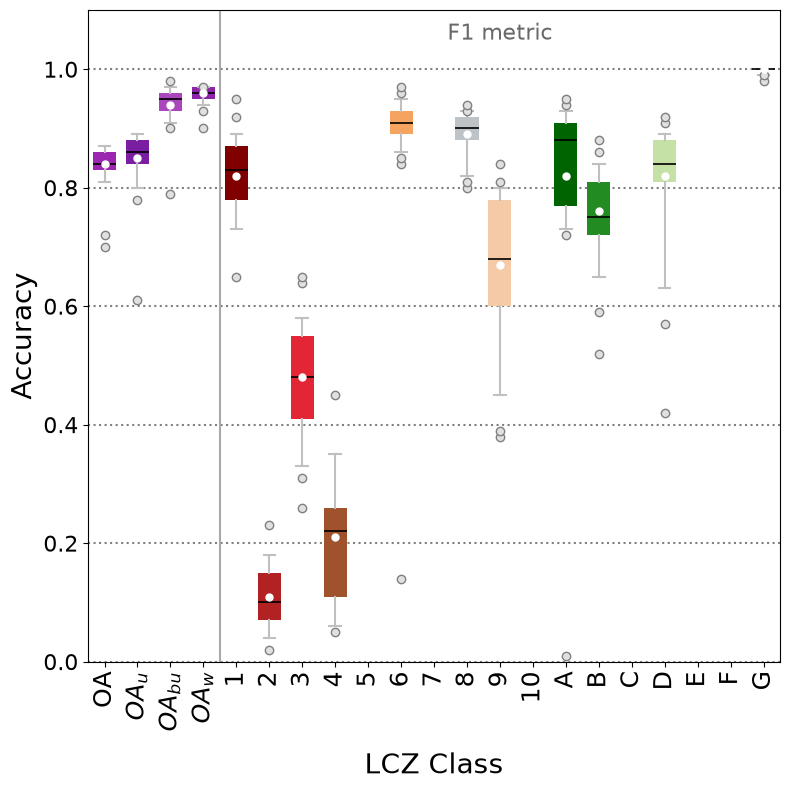

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the summary statistics
# Ensure the CSV file is in the same directory as this script
df = pd.read_csv('../data/csv/04_level0_F1_score_csv.csv', low_memory=False)

# 2. Define the full list of classes (including the empty ones on the X-axis)
all_classes = [
    'OA', 'OA_u', 'OA_bu', 'OA_w', '1', '2', '3', '4', '5', 
    '6', '7', '8', '9', '10', 'A', 'B', 'C', 'D', 'E', 'F', 'G'
]

# 3. Define the approximate colors for the boxes based on the original image
colors = {
    'OA': '#9b27b0', 'OA_u': '#7b1fa2', 'OA_bu': '#ab47bc', 'OA_w': '#8e24aa',
    '1': '#800000', '2': '#b22222', '3': '#e32636', '4': '#a0522d',
    '6': '#f4a460', '8': '#bdc3c7', '9': '#f5cba7',
    'A': '#006400', 'B': '#228b22', 'D': '#c5e1a5', 'G': '#191970'
}

valid_stats = []
valid_positions = []
box_colors = []

# Initialize the plot
fig, ax = plt.subplots(figsize=(8, 8))

# 4. Process the data into the dictionary format required by matplotlib's bxp
for i, cls in enumerate(all_classes, start=1):
    row = df[df['Class'] == cls]
    
    if not row.empty:
        r = row.iloc[0]
        
        # Parse outliers from the comma-separated string
        outliers = []
        if pd.notna(r['Outliers']):
            outliers = [float(x.strip()) for x in str(r['Outliers']).split(',')]
        
        # Special handling for Class 6 (only has an outlier, no box structure)
        if pd.isna(r['Q1']):
            ax.plot([i] * len(outliers), outliers, 'o', markerfacecolor='#e0e0e0', 
                    markeredgecolor='grey', markersize=6)
        else:
            # Prepare the stats dictionary for standard boxes
            stat = {
                'label': cls,
                'whislo': r['Lower_Whisker'],
                'q1': r['Q1'],
                'med': r['Median'],
                'q3': r['Q3'],
                'whishi': r['Upper_Whisker'],
                'fliers': outliers,
                'mean': r['Mean'] if pd.notna(r['Mean']) else np.nan
            }
            
            valid_stats.append(stat)
            valid_positions.append(i)
            box_colors.append(colors.get(cls, 'white'))

# 5. Draw the boxplots using the summary statistics
bplot = ax.bxp(valid_stats, positions=valid_positions, showmeans=True, patch_artist=True, widths=0.7,
               meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'white', 'markersize':5},
               medianprops={'color':'black', 'linewidth': 1.2},
               flierprops={'marker':'o', 'markerfacecolor':'#e0e0e0', 'markeredgecolor':'grey', 'markersize':6},
               whiskerprops={'color': 'silver', 'linewidth': 1.5},
               capprops={'color': 'silver', 'linewidth': 1.5})

# Apply the designated colors to the boxes and remove borders
for patch, color in zip(bplot['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('none')

# 6. Recreate the visual styling, grids, and labels

# Y-axis bounds and ticks
ax.set_ylim(0.0, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('Accuracy', fontsize=20)
ax.tick_params(axis='y', labelsize=16)

# Horizontal grid lines (set behind the plots)
ax.yaxis.grid(True, linestyle=':', linewidth=1.5, color='grey')
ax.set_axisbelow(True)

# Vertical separation line (between OA_w at position 4 and class 1 at position 5)
ax.axvline(x=4.5, color='darkgray', linewidth=1.5)

# X-axis labels with LaTeX formatting for subscripts
x_labels = [
    'OA', r'$OA_u$', r'$OA_{bu}$', r'$OA_w$', '1', '2', '3', '4', '5', 
    '6', '7', '8', '9', '10', 'A', 'B', 'C', 'D', 'E', 'F', 'G'
]
ax.set_xticks(range(1, 22))
ax.set_xticklabels(x_labels, rotation=90, fontsize=18)
ax.set_xlabel('LCZ Class', fontsize=20, labelpad=15)

# Top floating text
ax.text(13, 1.05, 'F1 metric', fontsize=16, color='dimgrey', ha='center')

# Final layout adjustments
plt.tight_layout()

# Save the figure
output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'level0_accuracy_F1_metric.png'), dpi=300, bbox_inches='tight')

plt.show()

### 4.2.2 Characteristics of LCZ classes

C:\Users\percy\AppData\Local\Temp\ipykernel_30032\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_30032\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_30032\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\percy\AppData\Local\Temp\ipykernel_30032\536131120.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

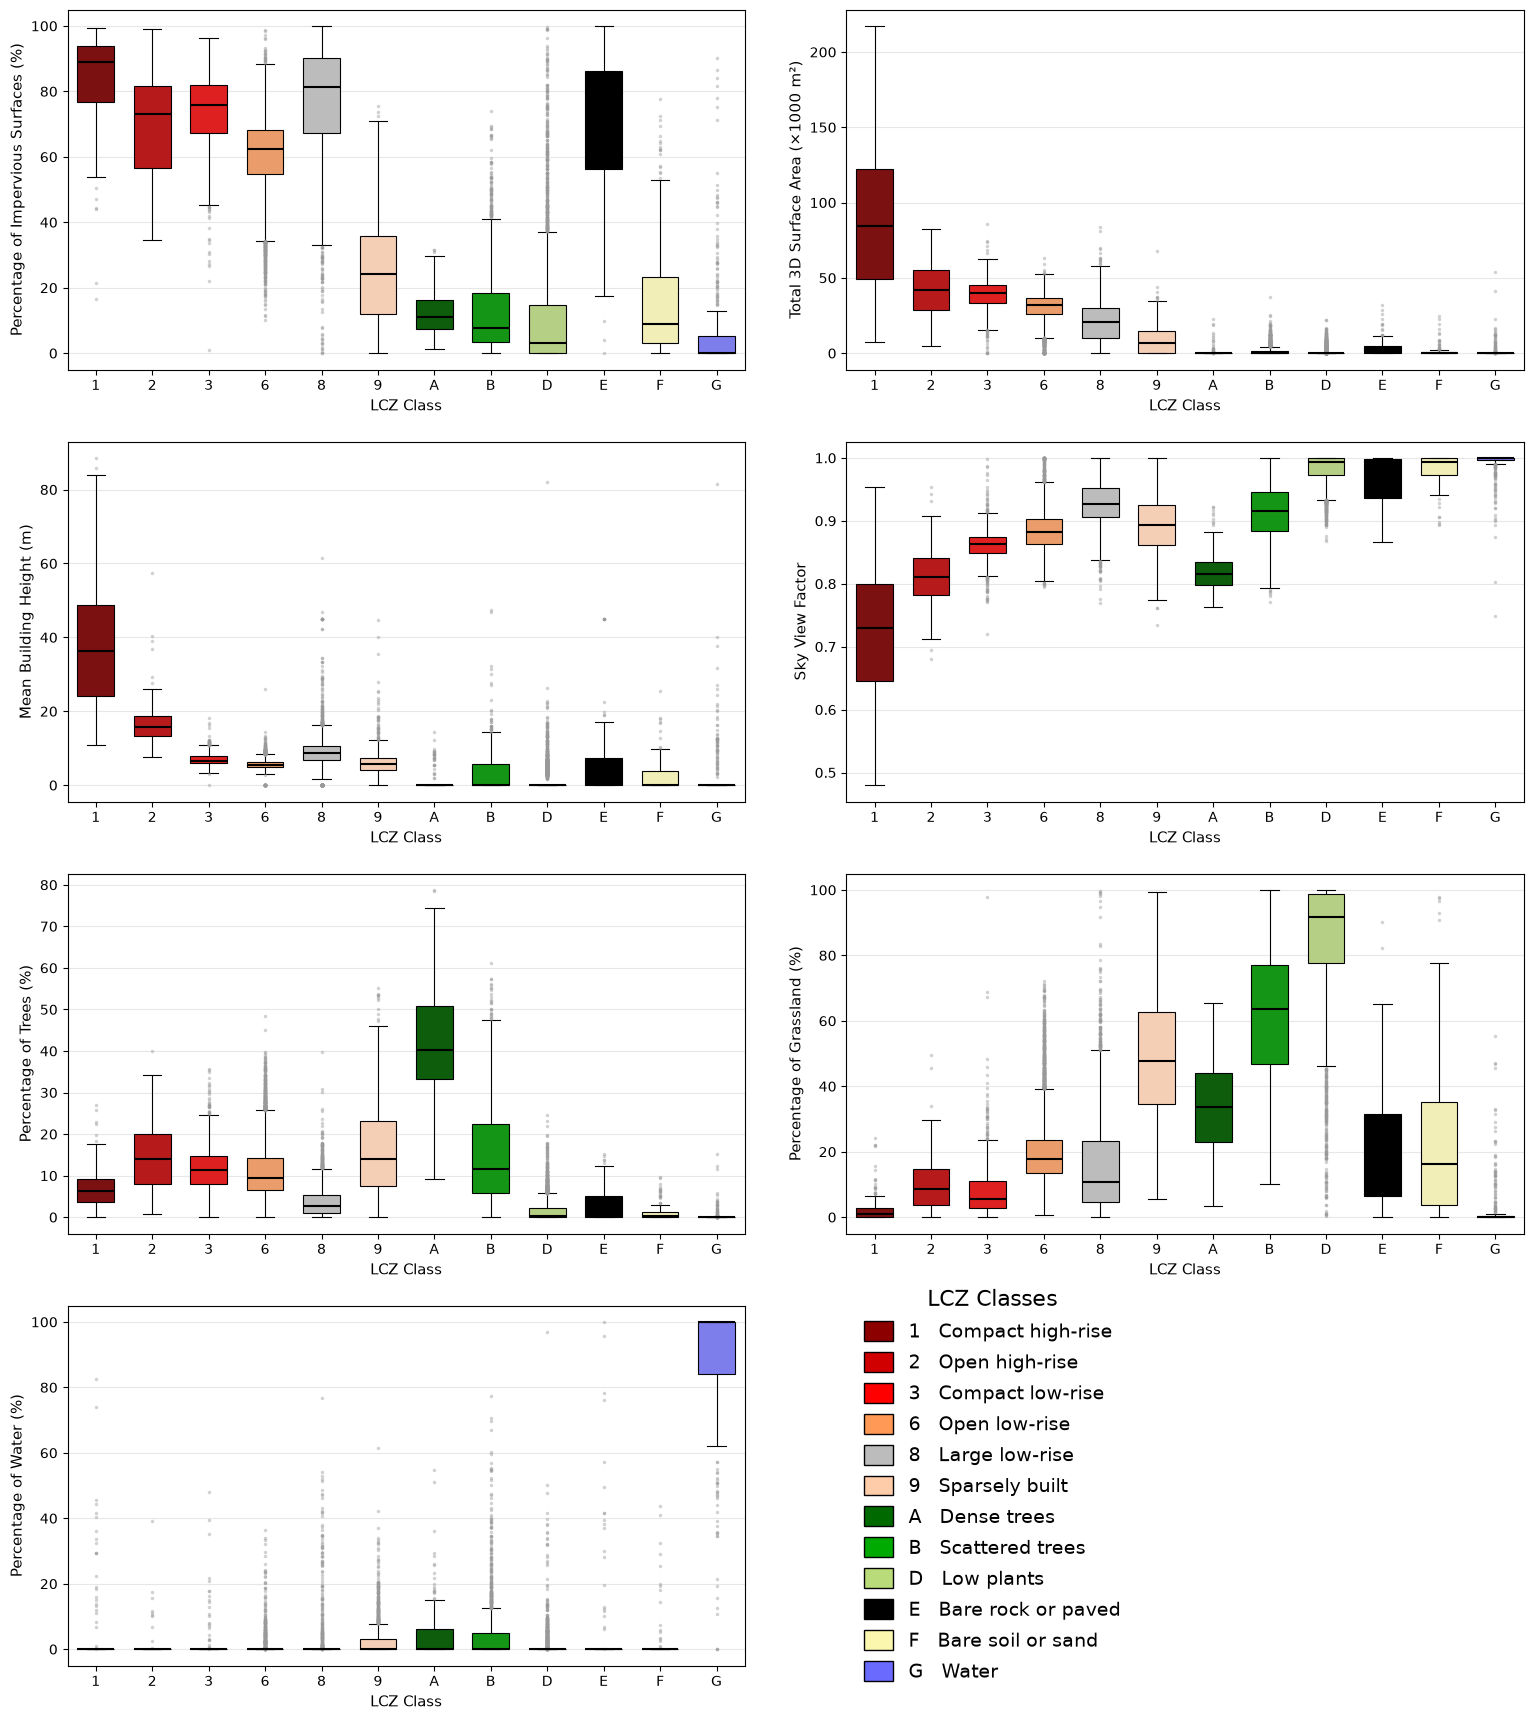

Saved: C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures\lcz_boxplots_panel.png


In [16]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Read data
# ------------------------------------------------------------------
df_landCover_builtUp_plot = pd.read_csv(
    '../data/csv/03_landCover_builtUp_exported_csv.csv'
)

output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------
# Variables
# ------------------------------------------------------------------
variables = [
    'per_impervious',
    'per_total_grass',
    'per_tree',
    'svf',
    'height',
    'wall_plan_area_m2',
    'per_water'
]

y_label_map = {
    'per_impervious': 'Percentage of Impervious Surfaces (%)',
    'per_total_grass': 'Percentage of Grassland (%)',
    'per_tree': 'Percentage of Trees (%)',
    'per_water': 'Percentage of Water (%)',
    'svf': 'Sky View Factor',
    'height': 'Mean Building Height (m)',
    'wall_plan_area_m2': 'Total 3D Surface Area (×1000 m²)'
}

lcz_label_map = {
    1: '1',
    2: '2',
    3: '3',
    6: '6',
    8: '8',
    9: '9',
    11: 'A',
    12: 'B',
    14: 'D',
    15: 'E',
    16: 'F',
    17: 'G'
}

color_map = {
    1: '#8c0000',
    2: '#d10000',
    3: '#ff0000',
    6: '#ff9955',
    8: '#bcbcbc',
    9: '#ffccaa',
    11: '#006a00',
    12: '#00aa00',
    14: '#b9db79',
    15: '#000000',
    16: '#fbf7ae',
    17: '#6a6aff'
}

# ------------------------------------------------------------------
# Prepare dataframe
# ------------------------------------------------------------------
plot_df = df_landCover_builtUp_plot.copy()

plot_df['lcz_label'] = plot_df['lcz'].map(lcz_label_map)
plot_df = plot_df.dropna(subset=['lcz_label'])

plot_df['wall_plan_area_m2_plot'] = (
    plot_df['wall_plan_area_m2'] / 1000
)

palette = {
    lcz_label_map[k]: color_map[k]
    for k in lcz_label_map
}

order = [lcz_label_map[k] for k in sorted(lcz_label_map)]

# ------------------------------------------------------------------
# Boxplot function
# ------------------------------------------------------------------
def make_boxplot(ax, var):

    y_var = (
        'wall_plan_area_m2_plot'
        if var == 'wall_plan_area_m2'
        else var
    )

    sns.boxplot(
        data=plot_df,
        x='lcz_label',
        y=y_var,
        order=order,
        palette=palette,
        linewidth=0.8,
        width=0.65,
        ax=ax,

        flierprops=dict(
            marker='o',
            markerfacecolor='0.6',
            markeredgecolor='none',
            markersize=2.5,
            alpha=0.45
        ),

        medianprops=dict(
            color='black',
            linewidth=1.5
        )
    )

    ax.set_xlabel('LCZ Class', fontsize=11)
    ax.set_ylabel(y_label_map[var], fontsize=11)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    ax.grid(axis='y', alpha=0.3)

# ------------------------------------------------------------------
# Create figure
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16,18)
)

axes = axes.flatten()

panel_order = [
    'per_impervious',
    'wall_plan_area_m2',
    'height',
    'svf',
    'per_tree',
    'per_total_grass',
    'per_water'
]

# ------------------------------------------------------------------
# Draw boxplots
# ------------------------------------------------------------------
for ax, var in zip(axes[:7], panel_order):
    make_boxplot(ax, var)

# ------------------------------------------------------------------
# Legend panel
# ------------------------------------------------------------------
legend_ax = axes[7]
legend_ax.axis('off')

legend_items = [
    (1, 'Compact high-rise'),
    (2, 'Open high-rise'),
    (3, 'Compact low-rise'),
    (6, 'Open low-rise'),
    (8, 'Large low-rise'),
    (9, 'Sparsely built'),
    (11, 'Dense trees'),
    (12, 'Scattered trees'),
    (14, 'Low plants'),
    (15, 'Bare rock or paved'),
    (16, 'Bare soil or sand'),
    (17, 'Water')
]

handles = [
    Patch(
        facecolor=color_map[lcz],
        edgecolor='black',
        label=f"{lcz_label_map[lcz]}   {name}"
    )
    for lcz, name in legend_items
]

legend_ax.legend(
    handles=handles,
    title='LCZ Classes',
    loc='center left',
    frameon=False,
    fontsize=14,
    title_fontsize=16,
    handlelength=1.5,
    handleheight=1.2
)

# ------------------------------------------------------------------
# Better spacing
# ------------------------------------------------------------------
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.98,
    bottom=0.06,
    wspace=0.15,
    hspace=0.20
)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
panel_path = os.path.join(
    output_dir,
    'lcz_boxplots_panel.png'
)

plt.savefig(
    panel_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved: {panel_path}')

### 4.2.3 Level 1 Summary F1 metric

In [17]:
####################################################
# Imports
####################################################
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    confusion_matrix
)

####################################################
# Data
####################################################
X = plot_df[variables]
y = plot_df["lcz"]

####################################################
# Fix LCZ labels (CRITICAL)
####################################################
y = y.astype(str)

####################################################
# Repeated random split
####################################################
n_runs = 30

sss = StratifiedShuffleSplit(
    n_splits=n_runs,
    test_size=0.30,
    random_state=42
)

results = []

built_up_classes = [
    "LCZ1","LCZ2","LCZ3","LCZ4","LCZ5",
    "LCZ6","LCZ7","LCZ8","LCZ9","LCZ10",
    "1","2","3","4","5","6","7","8","9","10",
    1,2,3,4,5,6,7,8,9,10
]

####################################################
# LOOP
####################################################
for train_idx, test_idx in sss.split(X, y):

    ################################################
    # Split
    ################################################
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    ################################################
    # Train model
    ################################################
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=None
    )

    rf.fit(X_train, y_train)

    ################################################
    # Predict (BEFORE confusion matrix)
    ################################################
    pred = rf.predict(X_test)

    ################################################
    # Overall Accuracy
    ################################################
    oa = accuracy_score(y_test, pred)

    ################################################
    # Built-up OA
    ################################################
    mask = y_test.isin(built_up_classes)

    if mask.sum() > 0:
        oabu = accuracy_score(y_test[mask], pred[mask])
    else:
        oabu = np.nan

    ################################################
    # OAw (correct version)
    ################################################
    labels = np.unique(y)

    cm = confusion_matrix(
        y_test,
        pred,
        labels=labels,
        normalize='true'
    )

    oaw = np.trace(cm) / cm.shape[0]

    ################################################
    # Producer’s accuracy (Recall)
    ################################################
    recalls = recall_score(
        y_test,
        pred,
        labels=labels,
        average=None,
        zero_division=0
    )

    ################################################
    # Store results
    ################################################
    row = {
        "OA": oa,
        "OAbu": oabu,
        "OAw": oaw
    }

    for cls, rec in zip(labels, recalls):
        row[str(cls)] = rec

    results.append(row)

####################################################
# Final DataFrame
####################################################
results = pd.DataFrame(results)

print(results.head())

####################################################
# Summary statistics (recommended)
####################################################
print("\n===== SUMMARY =====")
print(results[["OA", "OAbu", "OAw"]].agg(["mean", "std"]))

         OA      OAbu       OAw      1        11        12        14  \
0  0.797521  0.813981  0.624332  0.675  0.488889  0.539256  0.878597   
1  0.795868  0.810664  0.611838  0.775  0.555556  0.522727  0.895683   
2  0.801983  0.816114  0.636476  0.750  0.622222  0.533058  0.890288   
3  0.798512  0.812085  0.623600  0.725  0.555556  0.533058  0.895683   
4  0.795537  0.811611  0.612368  0.725  0.555556  0.518595  0.883094   

         15        16        17         2         3         6         8  \
0  0.095238  0.707317  0.915094  0.478261  0.488095  0.923077  0.804145   
1  0.095238  0.560976  0.877358  0.434783  0.400794  0.926779  0.802073   
2  0.119048  0.658537  0.943396  0.434783  0.440476  0.924311  0.818653   
3  0.095238  0.560976  0.924528  0.521739  0.464286  0.923077  0.814508   
4  0.095238  0.634146  0.943396  0.347826  0.448413  0.930070  0.809326   

          9  
0  0.499018  
1  0.495088  
2  0.502947  
3  0.469548  
4  0.457760  

===== SUMMARY =====
           

In [18]:
# Build summary statistics for the results
import numpy as np
import pandas as pd

cols = ["OA", "OAbu", "OAw"] + [
    c for c in results.columns
    if c not in ["OA", "OAbu", "OAw"]
]

def build_box_stats(df, col):
    values = df[col].dropna().values

    q1 = np.percentile(values, 25)
    med = np.percentile(values, 50)
    q3 = np.percentile(values, 75)

    iqr = q3 - q1

    lower_whisker = np.min(values[values >= q1 - 1.5 * iqr])
    upper_whisker = np.max(values[values <= q3 + 1.5 * iqr])

    outliers = values[(values < lower_whisker) | (values > upper_whisker)]

    return {
        "Class": col,
        "Mean": np.mean(values),
        "Median": med,
        "Q1": q1,
        "Q3": q3,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outliers": ",".join(map(str, outliers)) if len(outliers) > 0 else np.nan
    }

df_summary = pd.DataFrame([
    build_box_stats(results, c) for c in cols
])

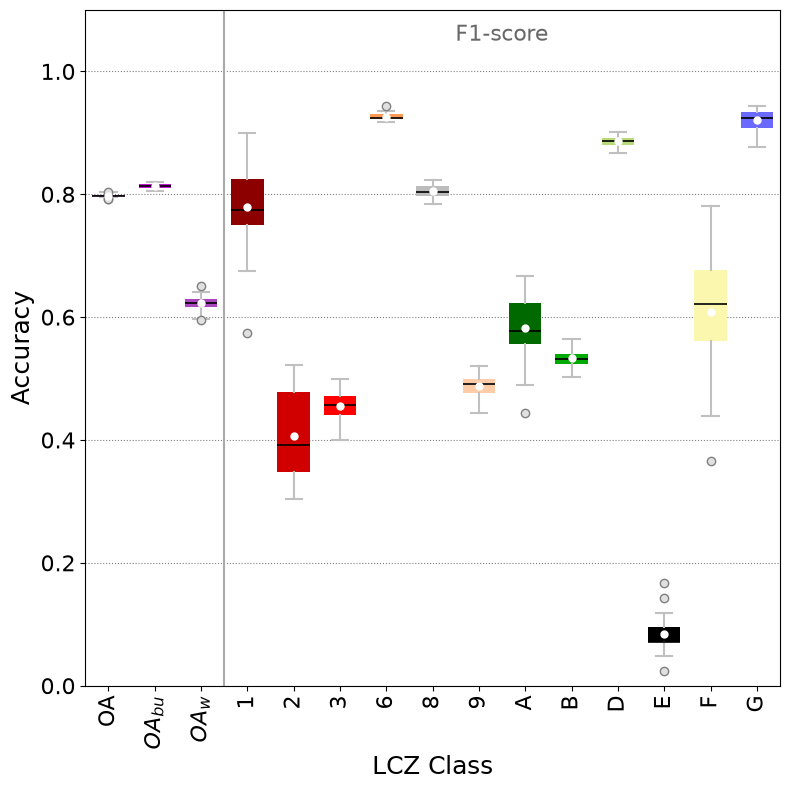

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

df_summary["Class"] = df_summary["Class"].replace({
    "11": "A",
    "12": "B",
    "14": "D",
    "15": "E",
    "16": "F",
    "17": "G"
})

####################################################
# Color map (your version)
####################################################
colors = {
    "OA": "#9c27b0",
    "OAbu": "#c218d0",
    "OAw": "#ab47bc",

    "1": "#8c0000",
    "2": "#d10000",
    "3": "#ff0000",
    "6": "#ff9955",
    "8": "#bcbcbc",
    "9": "#ffccaa",

    "A": "#006a00",
    "B": "#00aa00",
    "D": "#b9db79",
    "E": "#000000",
    "F": "#fbf7ae",
    "G": "#6a6aff"
}

####################################################
# Ensure correct class order (based on your data)
####################################################
all_classes = [
    "OA", "OAbu", "OAw",
    "1","2","3","6","8","9",
    "A","B","D","E","F","G"
]

####################################################
# Build boxplot stats
####################################################
valid_stats = []
valid_positions = []
box_colors = []

fig, ax = plt.subplots(figsize=(8, 8))

for i, cls in enumerate(all_classes, start=1):

    row = df_summary[df_summary["Class"] == cls]

    if row.empty:
        continue

    r = row.iloc[0]

    outliers = []
    if pd.notna(r["Outliers"]):
        outliers = [float(x) for x in str(r["Outliers"]).split(",")]

    stat = {
        "label": cls,
        "whislo": r["Lower_Whisker"],
        "q1": r["Q1"],
        "med": r["Median"],
        "q3": r["Q3"],
        "whishi": r["Upper_Whisker"],
        "fliers": outliers,
        "mean": r["Mean"]
    }

    valid_stats.append(stat)
    valid_positions.append(i)
    box_colors.append(colors.get(cls, "lightgrey"))

####################################################
# Plot
####################################################
bplot = ax.bxp(
    valid_stats,
    positions=valid_positions,
    showmeans=True,
    patch_artist=True,
    widths=0.7,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "white",
        "markersize": 5
    },
    medianprops={
        "color": "black",
        "linewidth": 1.2
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "#e0e0e0",
        "markeredgecolor": "grey",
        "markersize": 6
    },
    whiskerprops={
        "color": "silver",
        "linewidth": 1.5
    },
    capprops={
        "color": "silver",
        "linewidth": 1.5
    }
)

####################################################
# Apply colors
####################################################
for patch, color in zip(bplot["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("none")

####################################################
# Styling
####################################################
ax.set_ylim(0, 1.1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel("Accuracy", fontsize=18)

ax.yaxis.grid(True, linestyle=":", color="grey")
ax.set_axisbelow(True)

ax.axvline(x=3.5, color="darkgray", linewidth=1.5)

####################################################
# X labels
####################################################
x_labels = ["OA", r"$OA_{bu}$", r"$OA_w$"] + [
    str(c) for c in all_classes[3:]
]
#ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(range(1, len(valid_stats) + 1))
ax.set_xticklabels(x_labels, rotation=90, fontsize=16)

ax.set_xlabel("LCZ Class", fontsize=18)

ax.text(
    9.5,
    1.05,
    "F1-score",
    fontsize=16,
    color="dimgray",
    ha="center"
)


####################################################
# Layout + Save
####################################################
plt.tight_layout()

output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, 'level1_accuracy_F1_metric.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 4.2.4 Level 1 Confusion matrix

In [20]:
print(sorted(pd.unique(y_test.astype(str))))
print(sorted(pd.unique(pd.Series(pred).astype(str))))

['1', '11', '12', '14', '15', '16', '17', '2', '3', '6', '8', '9']
['1', '11', '12', '14', '15', '16', '17', '2', '3', '6', '8', '9']


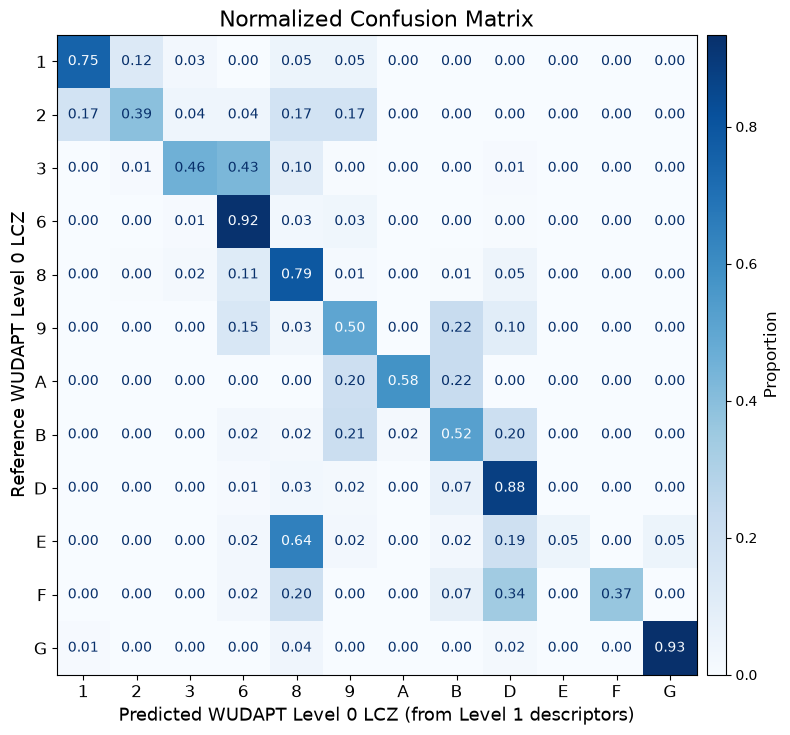

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import os

####################################################
# STEP 1 — RECODE 11–17 → A–F
####################################################
mapping = {
    "11": "A",
    "12": "B",
    "14": "D",
    "15": "E",
    "16": "F",
    "17": "G"
}

y_true = y_test.astype(str).replace(mapping)
y_pred = pd.Series(pred).astype(str).replace(mapping)

####################################################
# STEP 2 — FINAL ORDER (IMPORTANT)
####################################################
labels = ['1', '2', '3', '6', '8', '9', 'A', 'B', 'D', 'E', 'F', 'G']

####################################################
# STEP 3 — CONFUSION MATRIX
####################################################
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels,
    normalize='true'
)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format=".2f",
    xticks_rotation=45,
    colorbar=False
)

####################################################
# STEP 4 — CLEAN AXIS LABELS (NO INT CASTING ANYMORE)
####################################################
ax.set_xticklabels(
    [lcz_label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    rotation=0,
    ha='center',
    fontsize=12
)

ax.set_yticklabels(
    [lcz_label_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()],
    rotation=0,
    fontsize=12
)

####################################################
# STEP 5 — COLORBAR (aligned)
####################################################
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cbar = fig.colorbar(disp.im_, cax=cax)
cbar.set_label('Proportion', fontsize=12)
cbar.ax.tick_params(labelsize=10)

####################################################
# STEP 6 — TITLES
####################################################
ax.set_title('Normalized Confusion Matrix', fontsize=16)
ax.set_xlabel('Predicted WUDAPT Level 0 LCZ (from Level 1 descriptors)', fontsize=13)
ax.set_ylabel('Reference WUDAPT Level 0 LCZ', fontsize=13)

plt.tight_layout()

####################################################
# STEP 7 — SAVE FIGURE
####################################################
output_dir = r'C:\Users\percy\Documents\studies\visual_studio_code\PhD_Chapter_3_LOCATE\output\figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, 'level1_confusion_matrix.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()